# Metoda B — Bezpośrednie porównanie par (Qwen)

Qwen2-VL opisuje różnice między parami obrazów z plików CSV w `similarity_results/`.  
Wynik zapisywany jest do `results_B/results_B_{label}.csv` (oryginalne kolumny + `qwen_description`).

## 1. Importy

In [1]:
import gc
import textwrap
from pathlib import Path

In [2]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
import torch

In [4]:
from datasets import load_dataset
from IPython.display import display as ipy_display
from PIL import Image
from tqdm.auto import tqdm
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration

In [5]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Urządzenie: {DEVICE}")

Urządzenie: cuda


In [ ]:
# import gc
# import textwrap
# from pathlib import Path

# import matplotlib.gridspec as gridspec
# import matplotlib.pyplot as plt
# import pandas as pd
# import torch
# from datasets import load_dataset
# from IPython.display import display as ipy_display
# from PIL import Image
# from tqdm.auto import tqdm
# from transformers import AutoProcessor, Qwen2VLForConditionalGeneration

# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# print(f"Urządzenie: {DEVICE}")

## 2. Konfiguracja

In [36]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# KONFIGURACJA — zmień te parametry przed uruchomieniem
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Co przetwarzać:
#   "caltech"  — wszystkie pliki *caltech* z similarity_results/
#   "imagenet" — wszystkie pliki *imagenet* z similarity_results/
#   "all"      — wszystkie pliki z similarity_results/
#   lista      — konkretne pliki, np.:
#                ["clip_caltech_blind_spots.csv", "dino_imagenet_test_blind_spots.csv"]
SELECTION = ["clip_caltech_blind_spots.csv"]

DISPLAY_N = 10    # ile par wyświetlić po przetworzeniu

QWEN_ID        = "Qwen/Qwen2-VL-2B-Instruct"
SIMILARITY_DIR = Path("similarity_results")
CACHE_DIR      = Path("img_cache")
OUTPUT_DIR     = Path("results_B")
OUTPUT_DIR.mkdir(exist_ok=True)

## 3. Wybór plików CSV

In [7]:
all_csvs = sorted(SIMILARITY_DIR.glob("*.csv"))

if SELECTION == "caltech":
    selected = [f for f in all_csvs if "caltech" in f.name]
    run_label = "caltech"
elif SELECTION == "imagenet":
    selected = [f for f in all_csvs if "imagenet" in f.name]
    run_label = "imagenet"
elif SELECTION == "all":
    selected = all_csvs
    run_label = "all"
else:
    selected = [SIMILARITY_DIR / f for f in SELECTION]
    stems = [Path(f).stem.replace("_blind_spots", "") for f in SELECTION]
    run_label = "_".join(stems)

output_path = OUTPUT_DIR / f"results_B_{run_label}.csv"
print(f"Plik wyjściowy: {output_path}")
print(f"Wybrane pliki ({len(selected)}):")
for f in selected:
    print(f"  {f.name}")

Plik wyjściowy: results_B\results_B_clip_caltech.csv
Wybrane pliki (1):
  clip_caltech_blind_spots.csv


## 4. Logowanie HuggingFace

In [9]:
from huggingface_hub import notebook_login
notebook_login()

ImportError: The `notebook_login` function can only be used in a notebook (Jupyter or Colab) and you need the `ipywidgets` module: `pip install ipywidgets`.

## 5. Wczytanie datasetów

In [8]:
def add_index(sample, idx):
    sample["id"] = idx
    return sample

DATASETS = {}

if any("caltech" in f.name for f in selected):
    print("Wczytywanie Caltech101...")
    DATASETS["caltech"] = load_dataset("flwrlabs/caltech101", split="train", trust_remote_code=True)
    print("  ✓ Caltech101")

if any("imagenet" in f.name for f in selected):
    print("Wczytywanie ImageNet-1k (test, streaming)...")
    ds = load_dataset("imagenet-1k", split="test", streaming=True, trust_remote_code=True)
    DATASETS["imagenet"] = ds.map(add_index, with_indices=True)
    print("  ✓ ImageNet-test (streaming)")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'flwrlabs/caltech101' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Wczytywanie Caltech101...
  ✓ Caltech101


## 6. Cache obrazków

In [9]:
def dataset_key(csv_path: Path) -> str:
    return "caltech" if "caltech" in csv_path.name else "imagenet"


def prefetch_pairs(df: pd.DataFrame, key: str) -> None:
    ds = DATASETS[key]
    ids = set(df["id_1"].astype(int)) | set(df["id_2"].astype(int))
    out_dir = CACHE_DIR / key
    out_dir.mkdir(parents=True, exist_ok=True)
    missing = {i for i in ids if not (out_dir / f"{i}.jpg").exists()}
    if not missing:
        print(f"  [{key}] wszystko w cache")
        return
    print(f"  Pobieram {len(missing)} obrazków [{key}]...")
    if key == "caltech":
        for i in tqdm(sorted(missing)):
            ds[i]["image"].convert("RGB").save(out_dir / f"{i}.jpg", "JPEG")
    else:
        max_id = max(missing)
        for cur, sample in enumerate(tqdm(iter(ds), total=max_id + 1)):
            if cur in missing:
                sample["image"].convert("RGB").save(out_dir / f"{cur}.jpg", "JPEG")
                missing.discard(cur)
            if cur >= max_id or not missing:
                break


for csv_path in selected:
    df_tmp = pd.read_csv(csv_path, sep=";", index_col=0)
    prefetch_pairs(df_tmp, dataset_key(csv_path))
print("Cache gotowy.")

  [caltech] wszystko w cache
Cache gotowy.


## 7. Ładowanie Qwena

In [10]:
print(f"Ładowanie Qwen ({QWEN_ID})...")
qwen_processor = AutoProcessor.from_pretrained(QWEN_ID)
qwen_model = Qwen2VLForConditionalGeneration.from_pretrained(
    QWEN_ID, torch_dtype=torch.bfloat16, device_map="auto"
)
qwen_model.eval()

devices = {str(p.device) for p in qwen_model.parameters()}
print(f"Qwen gotowy | urządzenia: {', '.join(sorted(devices))}")

Ładowanie Qwen (Qwen/Qwen2-VL-2B-Instruct)...


The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Qwen gotowy | urządzenia: cuda:0


## 8. Funkcje pomocnicze

In [30]:
# QWEN_PROMPT v1 — ogólny około 3 minut na 194 parach zawsze dawał no diff dla pliku clip_caltech_blind_spots.csv
# QWEN_PROMPT = (
#     "Look carefully at these two images.\n"
#     "List the specific visual differences between image 1 (left) and image 2 (right).\n"
#     "Be precise: mention objects, colors, orientation, count, and any visible changes.\n"
#     "Do not repeat the same observation. If there are no differences, say 'No visible differences.'"
# )

# QWEN_PROMPT v2 — bez kategorii około 3 minut na 194 parach zawsze dawał no diff dla pliku clip_caltech_blind_spots.csv
# QWEN_PROMPT = (
#     "Analyze these two images carefully.\n"
#     "Write a detailed description of the exact differences between the two images.\n"
#     "Consider: objects, colors, orientation, count, position, lighting, shape, text, and camera angle.\n"
#     "If the images are identical, say 'No visible differences.'\n"
#     "Respond with plain text only — no JSON, no bullet points, no categories."
# )

# QWEN_PROMPT v3 — agresywny, wymusza szukanie różnic już pokazuje że będzie działał 42 minuty na 194 parach
# QWEN_PROMPT = (
#     "These two images come from a dataset of visual blind spots — pairs that look similar "
#     "but contain real, specific differences. Your job is to find them.\n\n"
#     "Examine both images pixel by pixel. Look at:\n"
#     "- background details (objects, textures, patterns)\n"
#     "- lighting and shadows\n"
#     "- colors and saturation\n"
#     "- object positions, sizes, and orientations\n"
#     "- small details: text, logos, accessories, decorations\n"
#     "- cropping and framing\n\n"
#     "You MUST describe what is different. Even subtle differences like slight color shift, "
#     "minor rotation, or a missing small element count. "
#     "Never say the images are identical — there is always something. "
#     "Write a detailed paragraph in plain text."
# )

# QWEN_PROMPT v4 — tak/nie o tle (użyj MAX_NEW_TOKENS = 5)
QWEN_PROMPT = (
    "Look at these two images. Do the backgrounds differ between the two images? "
    "Answer with a single word: yes or no."
)

MAX_NEW_TOKENS = 5  # dla promptów yes/no; ustaw 150+ dla promptów opisowych


def qwen_describe(img1: Image.Image, img2: Image.Image) -> str:
    content = [
        {"type": "image", "image": img1},
        {"type": "image", "image": img2},
        {"type": "text",  "text": QWEN_PROMPT},
    ]
    messages = [{"role": "user", "content": content}]
    text = qwen_processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = qwen_processor(
        text=[text], images=[img1, img2], return_tensors="pt"
    ).to(DEVICE)
    with torch.no_grad():
        gen = qwen_model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)
    trimmed = gen[0][inputs.input_ids.shape[1]:]
    del inputs, gen
    torch.cuda.empty_cache()
    return qwen_processor.decode(trimmed, skip_special_tokens=True).strip()


def load_images(row: pd.Series, key: str) -> tuple[Image.Image, Image.Image]:
    base = CACHE_DIR / key
    img1 = Image.open(base / f"{int(row['id_1'])}.jpg").convert("RGB")
    img2 = Image.open(base / f"{int(row['id_2'])}.jpg").convert("RGB")
    return img1, img2


def has_differences(desc: str) -> bool:
    d = str(desc).lower().strip()
    return d not in ("no", "no.") and "no visible differences" not in d


def show_pairs(results_df: pd.DataFrame, n: int = 5) -> None:
    filtered = results_df[results_df["qwen_description"].apply(has_differences)]
    if filtered.empty:
        print("Brak par z opisanymi różnicami.")
        return
    sample = filtered.sample(n=min(n, len(filtered))).reset_index(drop=True)
    print(f"Wyświetlam {len(sample)} z {len(filtered)} par z różnicami (pominięto {len(results_df) - len(filtered)} bez różnic).")
    for _, row in sample.iterrows():
        key = dataset_key(Path(row["source_file"]))
        img1 = Image.open(CACHE_DIR / key / f"{int(row['id_1'])}.jpg")
        img2 = Image.open(CACHE_DIR / key / f"{int(row['id_2'])}.jpg")

        fig = plt.figure(figsize=(10, 3.2))
        gs = gridspec.GridSpec(
            2, 2, height_ratios=[3, 1.2], hspace=0.08, wspace=0.05
        )

        for col, (img, label) in enumerate(
            [(img1, f"ID {int(row['id_1'])}"), (img2, f"ID {int(row['id_2'])}")]
        ):
            ax = fig.add_subplot(gs[0, col])
            ax.imshow(img)
            ax.set_title(label, fontsize=8, pad=2)
            ax.axis("off")

        ax_txt = fig.add_subplot(gs[1, :])
        ax_txt.axis("off")
        desc = textwrap.fill(str(row.get("qwen_description", "---")), width=120)
        ax_txt.text(
            0.5, 0.5, desc,
            ha="center", va="center", fontsize=7,
            bbox=dict(facecolor="#f5f5f5", edgecolor="#ccc", boxstyle="round,pad=0.4"),
            transform=ax_txt.transAxes,
        )

        src = Path(row["source_file"]).name
        plt.suptitle(
            f"{src}  |  model: {row['base_name']}  |  score: {row['score_base']:.3f}",
            fontsize=8, fontweight="bold", y=1.01,
        )
        plt.tight_layout()
        plt.show()
        print()

In [37]:
def show_pairs_yn(results_df: pd.DataFrame, n_each: int = 3) -> None:
    answers = results_df["qwen_description"].str.lower().str.strip()
    df_tak = results_df[answers.str.startswith("yes")]
    df_nie = results_df[answers.str.startswith("no")]

    for label, subset, color in [
        ("TAK — tła różne", df_tak, "#c8e6c9"),
        ("NIE — tła takie same", df_nie, "#ffcdd2"),
    ]:
        if subset.empty:
            print(f"Brak par z odpowiedzią: {label}")
            continue
        sample = subset.sample(n=min(n_each, len(subset))).reset_index(drop=True)
        print(f"\n{'━'*60}\n{label}  ({len(subset)} par łącznie)\n{'━'*60}")
        for _, row in sample.iterrows():
            key = dataset_key(Path(row["source_file"]))
            img1 = Image.open(CACHE_DIR / key / f"{int(row['id_1'])}.jpg")
            img2 = Image.open(CACHE_DIR / key / f"{int(row['id_2'])}.jpg")

            fig = plt.figure(figsize=(8, 2.8))
            gs = gridspec.GridSpec(1, 2, wspace=0.05)
            for col, (img, lbl) in enumerate(
                [(img1, f"ID {int(row['id_1'])}"), (img2, f"ID {int(row['id_2'])}")]
            ):
                ax = fig.add_subplot(gs[0, col])
                ax.imshow(img)
                ax.set_title(lbl, fontsize=8, pad=2)
                ax.axis("off")

            src = Path(row["source_file"]).name
            fig.patch.set_facecolor(color)
            plt.suptitle(
                f"{src}  |  {row['base_name']}  |  score: {row['score_base']:.3f}  |  tła różne: {row['qwen_description']}",
                fontsize=7, fontweight="bold", y=1.02,
            )
            plt.tight_layout()
            plt.show()

## 9. Przetwarzanie par

In [31]:
all_results = []

for csv_path in selected:
    print(f"\n{csv_path.name}")
    df = (
        pd.read_csv(csv_path, sep=";", index_col=0)
        .reset_index(drop=True)
    )
    key = dataset_key(csv_path)
    rows = []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        try:
            img1, img2 = load_images(row, key)
            desc = qwen_describe(img1, img2)
        except Exception as e:
            print(f"  BŁĄD {int(row['id_1'])}-{int(row['id_2'])}: {e}")
            desc = ""
        result = row.to_dict()
        result["qwen_description"] = desc
        result["source_file"] = str(csv_path)
        rows.append(result)
        gc.collect()

    all_results.extend(rows)
    print(f"{len(rows)} par")

results_df = pd.DataFrame(all_results)
print(f"\nŁącznie: {len(results_df)} par")
ipy_display(
    results_df[["id_1", "id_2", "base_name", "score_base", "qwen_description"]].head(3)
)


clip_caltech_blind_spots.csv


  0%|          | 0/194 [00:00<?, ?it/s]

194 par

Łącznie: 194 par


,id_1,id_2,base_name,score_base,qwen_description
0,20,465,CLIP,0.961227,yes
1,55,7297,CLIP,0.987392,yes
2,84,8550,CLIP,0.965167,yes


## 10. Wyświetlanie wyników

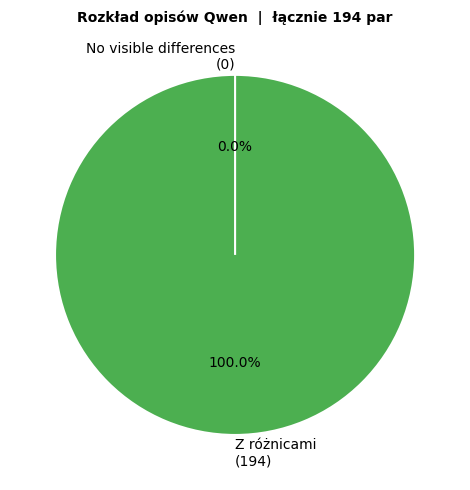

In [26]:
has_diff = results_df["qwen_description"].apply(has_differences)
counts = has_diff.value_counts()
n_diff   = counts.get(True, 0)
n_nodiff = counts.get(False, 0)

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    [n_diff, n_nodiff],
    labels=[f"Z różnicami\n({n_diff})", f"No visible differences\n({n_nodiff})"],
    autopct="%1.1f%%",
    colors=["#4caf50", "#e0e0e0"],
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=1.5),
)
ax.set_title(f"Rozkład opisów Qwen  |  łącznie {len(results_df)} par", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

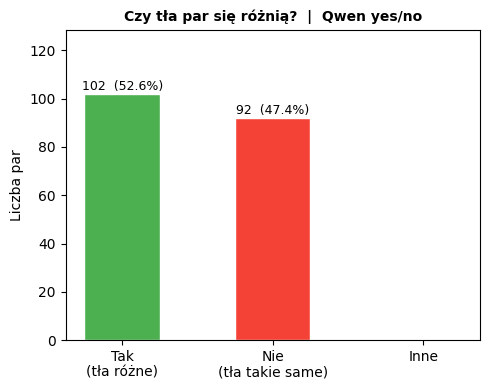

In [32]:
answers = results_df["qwen_description"].str.lower().str.strip()
n_tak = answers.str.startswith("yes").sum()
n_nie = answers.str.startswith("no").sum()
n_other = len(results_df) - n_tak - n_nie

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    ["Tak\n(tła różne)", "Nie\n(tła takie same)", "Inne"],
    [n_tak, n_nie, n_other],
    color=["#4caf50", "#f44336", "#e0e0e0"],
    edgecolor="white", width=0.5,
)
for bar, val in zip(bars, [n_tak, n_nie, n_other]):
    if val > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{val}  ({val / len(results_df) * 100:.1f}%)",
            ha="center", va="bottom", fontsize=9,
        )
ax.set_title("Czy tła par się różnią?  |  Qwen yes/no", fontsize=10, fontweight="bold")
ax.set_ylabel("Liczba par")
ax.set_ylim(0, max(n_tak, n_nie, n_other) * 1.25 + 1)
plt.tight_layout()
plt.show()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TAK — tła różne  (102 par łącznie)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


C:\Users\alapr\AppData\Local\Temp\ipykernel_26212\1854411216.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


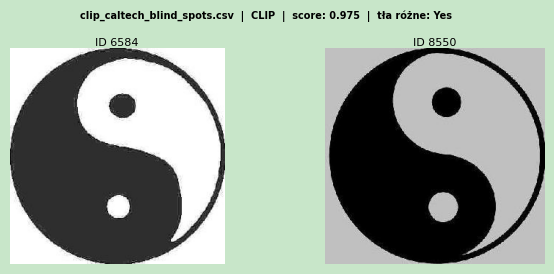

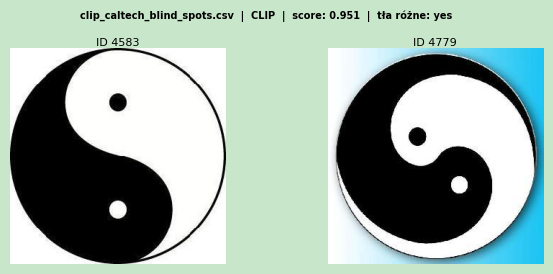

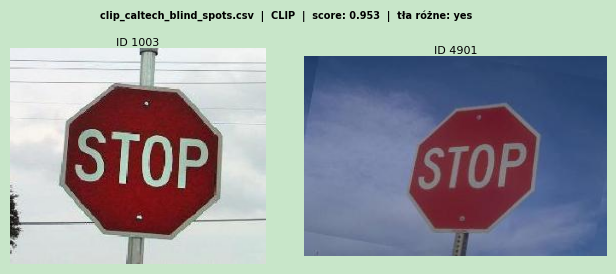

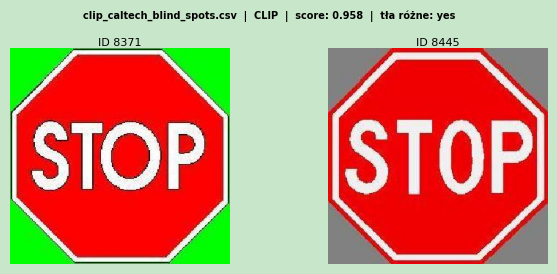

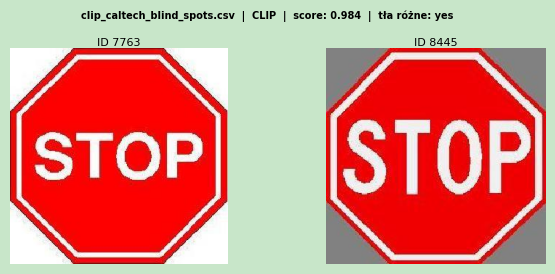

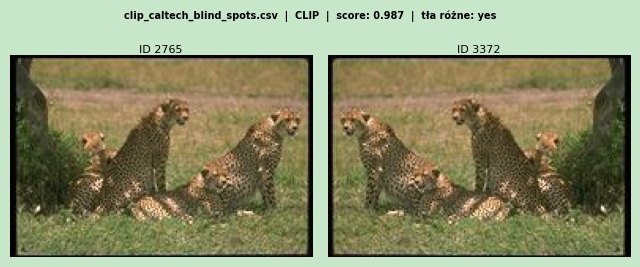

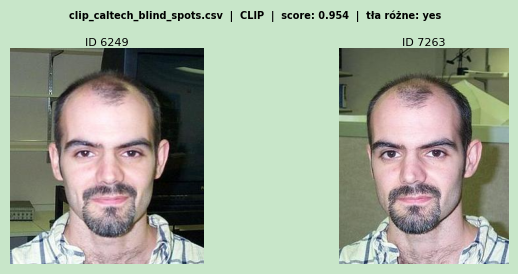

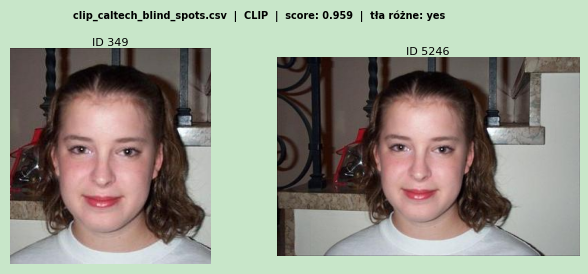

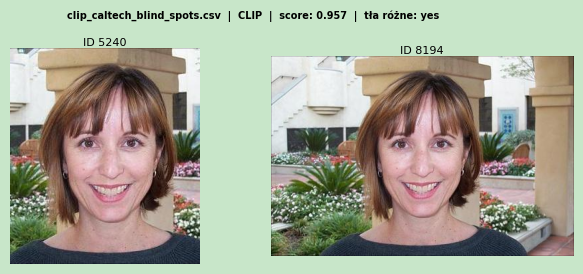

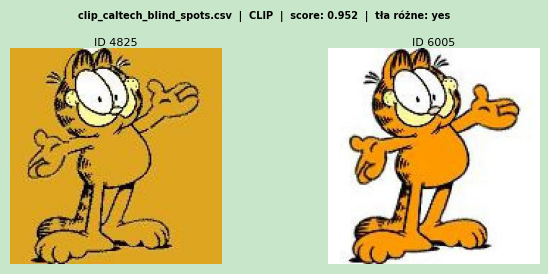


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
NIE — tła takie same  (92 par łącznie)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


C:\Users\alapr\AppData\Local\Temp\ipykernel_26212\1854411216.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


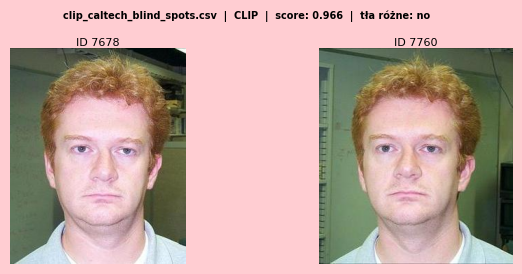

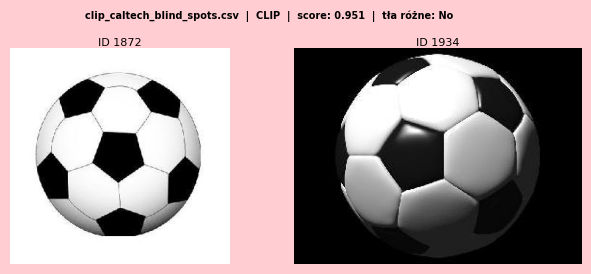

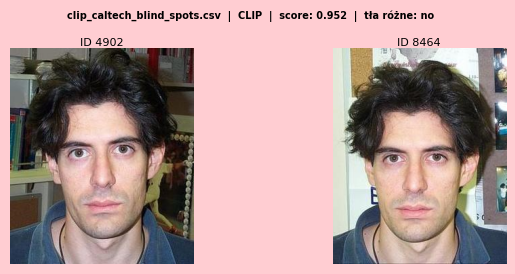

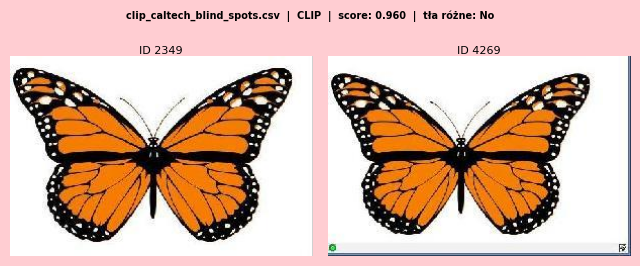

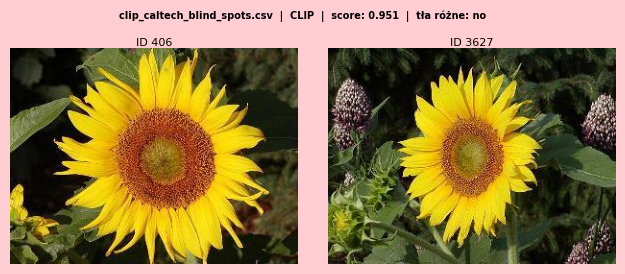

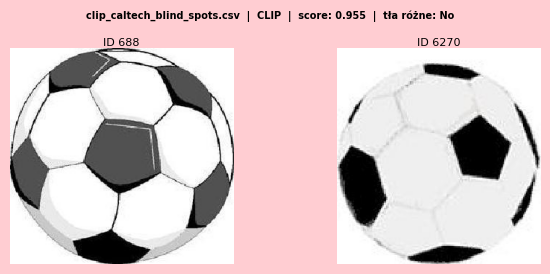

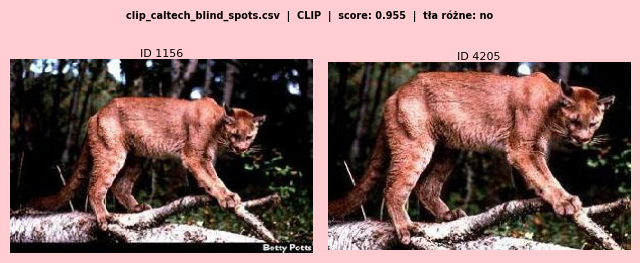

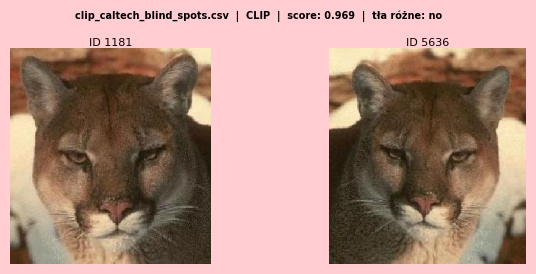

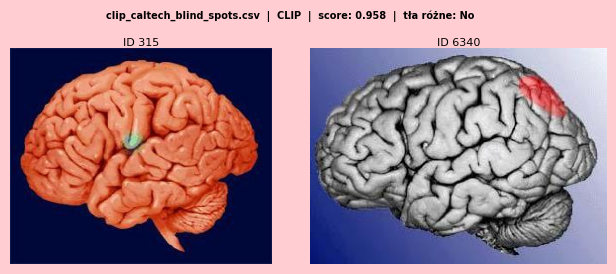

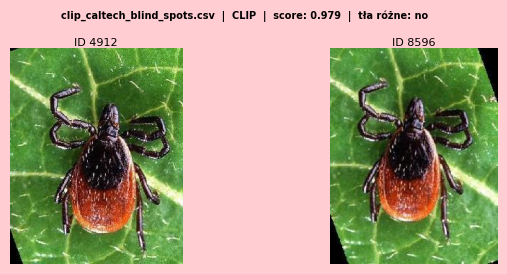

In [38]:
# Dla promptów opisowych (v1/v2/v3):
# show_pairs(results_df, n=DISPLAY_N)

# Dla promptu tak/nie (v4):
show_pairs_yn(results_df, n_each=DISPLAY_N)

## 11. Zapis wyników

In [28]:
results_df.to_csv(output_path, sep=";", index=False)
print(f"Zapisano: {output_path}  ({len(results_df)} wierszy)")
print(f"Kolumny: {list(results_df.columns)}")

Zapisano: results_B\results_B_clip_caltech.csv  (194 wierszy)
Kolumny: ['id_1', 'id_2', 'base_name', 'score_base', 'ref_1_name', 'score_ref_1', 'ref_2_name', 'score_ref_2', 'qwen_description', 'source_file']
